# Домашнее задание 

В этом задании мы попрактикуемся в методах снижения размерности и кластеризации данных. 

Мы будем работать с набором данных Samsung Human Activity Recognition. Данные поступают с акселерометров и гироскопов мобильных телефонов Samsung Galaxy S3, также известен вид активности человека с телефоном в кармане – ходил ли он, стоял, лежал, сидел или шел вверх/вниз по лестнице.

Представим, что вид активности нам неизвестнен, и попробуем кластеризовать людей чисто на основе имеющихся признаков.

In [109]:
import pandas as pd
import numpy as np
import seaborn as sns
from tqdm import tqdm_notebook

%matplotlib inline
from matplotlib import pyplot as plt
plt.style.use('ggplot')
plt.rcParams['figure.figsize'] = (12, 9)
plt.rcParams['font.family'] = 'DejaVu Sans'

from sklearn import metrics
from sklearn.cluster import KMeans, AgglomerativeClustering, SpectralClustering
from sklearn.decomposition import PCA
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC

RANDOM_STATE = 17

Для кластеризации нам не нужен вектор ответов. Объедините обучающую и тестовую выборки.

In [110]:
#your code here
test = pd.read_csv('/Users/katyamazurina/Desktop/2 sem/ML/test.csv')
train = pd.read_csv('/Users/katyamazurina/Desktop/2 sem/ML/train.csv')

In [111]:
data = pd.concat([test, train]) #объединяем данные

data.head()

,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",subject,Activity
0,0.257178,-0.023285,-0.014654,-0.938404,-0.920091,-0.667683,-0.952501,-0.925249,-0.674302,-0.894088,...,-0.705974,0.006462,0.162920,-0.825886,0.271151,-0.720009,0.276801,-0.057978,2,STANDING
1,0.286027,-0.013163,-0.119083,-0.975415,-0.967458,-0.944958,-0.986799,-0.968401,-0.945823,-0.894088,...,-0.594944,-0.083495,0.017500,-0.434375,0.920593,-0.698091,0.281343,-0.083898,2,STANDING
2,0.275485,-0.026050,-0.118152,-0.993819,-0.969926,-0.962748,-0.994403,-0.970735,-0.963483,-0.939260,...,-0.640736,-0.034956,0.202302,0.064103,0.145068,-0.702771,0.280083,-0.079346,2,STANDING
3,0.270298,-0.032614,-0.117520,-0.994743,-0.973268,-0.967091,-0.995274,-0.974471,-0.968897,-0.938610,...,-0.736124,-0.017067,0.154438,0.340134,0.296407,-0.698954,0.284114,-0.077108,2,STANDING
4,0.274833,-0.027848,-0.129527,-0.993852,-0.967445,-0.978295,-0.994111,-0.965953,-0.977346,-0.938610,...,-0.846595,-0.002223,-0.040046,0.736715,-0.118545,-0.692245,0.290722,-0.073857,2,STANDING


In [112]:
X = data.drop('Activity', axis=1)
y = data['Activity']

In [113]:
np.unique(y)

array(['LAYING', 'SITTING', 'STANDING', 'WALKING', 'WALKING_DOWNSTAIRS',
       'WALKING_UPSTAIRS'], dtype=object)

In [114]:
y = y.replace({'WALKING': 1, 'WALKING_UPSTAIRS': 2, 'WALKING_DOWNSTAIRS': 3, 'SITTING': 4, 'STANDING': 5, 'LAYING': 6})

/var/folders/mb/gxld42711bgbnqy7hrb9235c0000gn/T/ipykernel_4606/2028573275.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y = y.replace({'WALKING': 1, 'WALKING_UPSTAIRS': 2, 'WALKING_DOWNSTAIRS': 3, 'SITTING': 4, 'STANDING': 5, 'LAYING': 6})


Эти метки соответствуют:

1 - ходьбе,
2 - подъему вверх по лестнице,
3 - спуску по лестнице,
4 - сидению,
5 - стоянию,
6 - лежанию

Отмасштабируйте выборку с помощью StandardScaler.

In [115]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Понижаем размерность с помощью PCA, оставляя столько компонент, сколько нужно для того, чтобы объяснить как минимум 90% дисперсии исходных (отмасштабированных) данных. Используйте отмасштабированную выборку и зафиксируйте random_state.

In [116]:
pca = PCA().fit(X_scaled) #обучаем PCA на масштабированных данных
disp_info = np.cumsum(pca.explained_variance_ratio_) #накопленная доля объясненной дисперсии
n_comp = np.where(disp_info >= 0.9)[0][0] + 1

In [117]:
pca = PCA(n_components=n_comp)
X_pca = pca.fit_transform(X_scaled)

Визуализируйте данные в проекции на первые две главные компоненты.

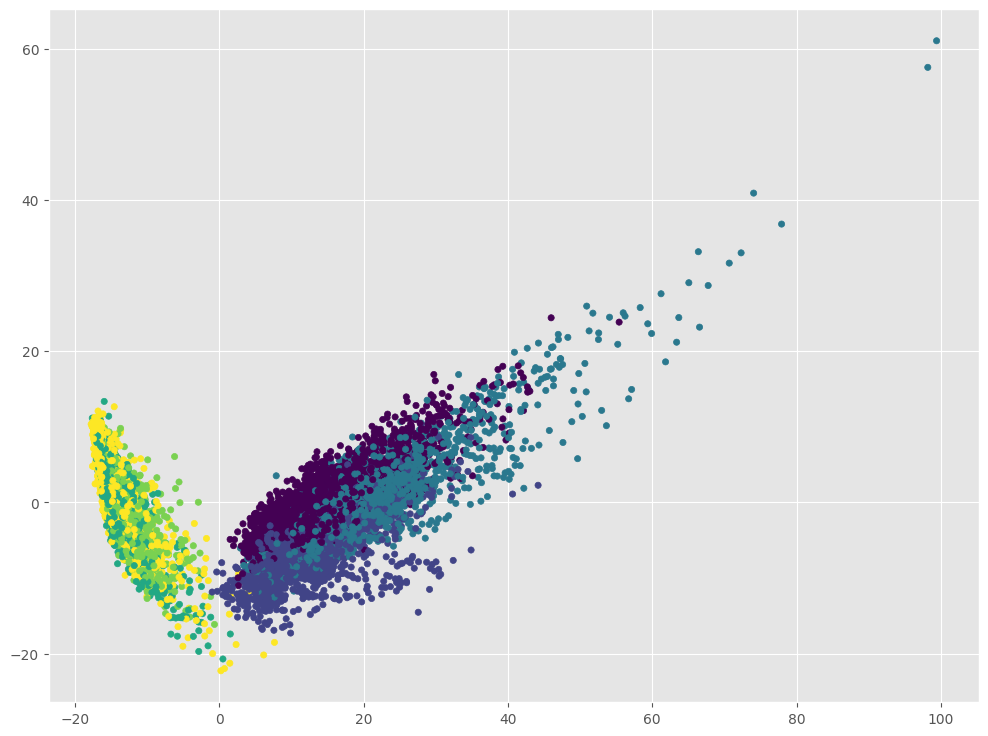

In [118]:
plt.scatter(X_pca[:,0], X_pca[:,1], c=y, s=20, cmap='viridis')

Сделайте кластеризацию данных методом KMeans, обучив модель на данных со сниженной за счет PCA размерностью. В данном случае нужно искать 6 кластеров (так как у нас 6 классов).

Параметры:

n_clusters = n_classes (число уникальных меток целевого класса)

n_init = 100

random_state = RANDOM_STATE (для воспроизводимости результата)

In [119]:
kmeans = KMeans(n_clusters=6, random_state=RANDOM_STATE, n_init=100)
kmeans.fit(X_pca)

KMeans(n_clusters=6, n_init=100, random_state=17)

Визуализируйте данные в проекции на первые две главные компоненты. Раскрасьте точки в соответствии с полученными метками кластеров.

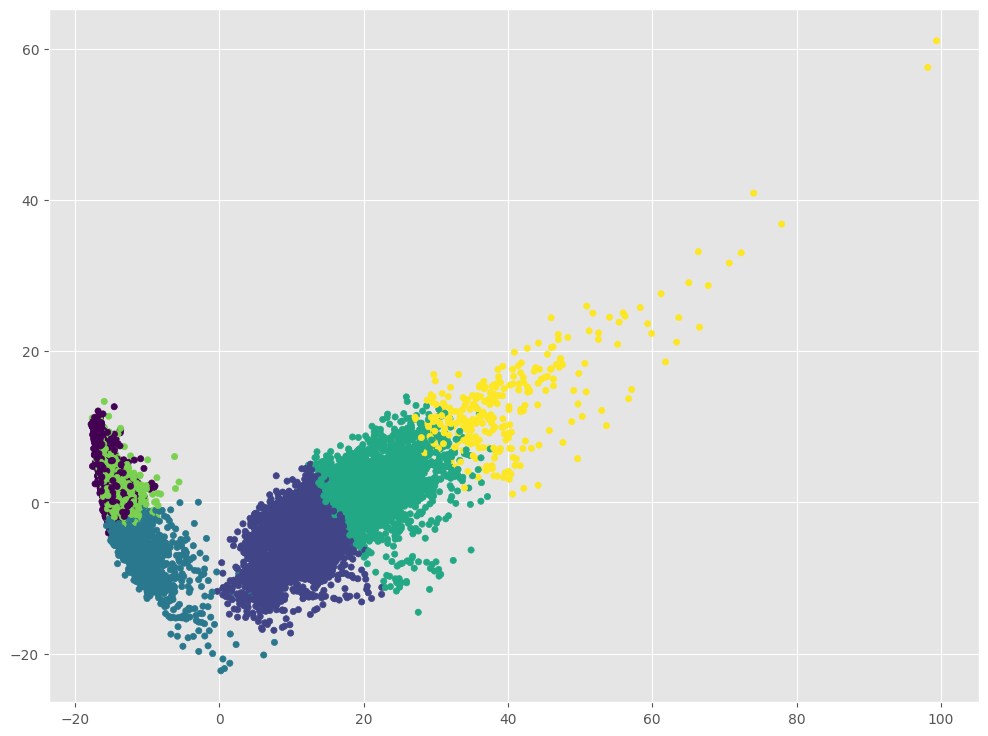

In [120]:
plt.scatter(X_pca[:,0], X_pca[:,1], c=kmeans.labels_, s=20, cmap='viridis')

Выведите на экран значения метрик качества кластеризации

In [124]:
km_y = kmeans.fit_predict(X_pca)

print("Homogeneity: %0.3f" % metrics.homogeneity_score(y, km_y))
print("Completeness: %0.3f" % metrics.completeness_score(y, km_y))
print("V-measure: %0.3f" % metrics.v_measure_score(y, km_y))
print("Adjusted Rand-Index: %.3f" % metrics.adjusted_rand_score(y, km_y))
print("Adjusted mutual info score: %.3f" % metrics.adjusted_mutual_info_score(y, km_y))
print("Silhouette Coefficient: %0.3f" % metrics.silhouette_score(X_pca, km_y, sample_size=1000))

Homogeneity: 0.541
Completeness: 0.581
V-measure: 0.560
Adjusted Rand-Index: 0.420
Adjusted mutual info score: 0.560
Silhouette Coefficient: 0.135


Теперь попробуем сделать кластеризацию с помощью AgglomerativeClustering (https://scikit-learn.org/stable/modules/generated/sklearn.cluster.AgglomerativeClustering.html)

In [125]:
ag = AgglomerativeClustering(n_clusters=6, 
                             linkage='ward').fit(X_pca)

ag.fit(X_pca)
ag_y = ag.fit_predict(X_pca)

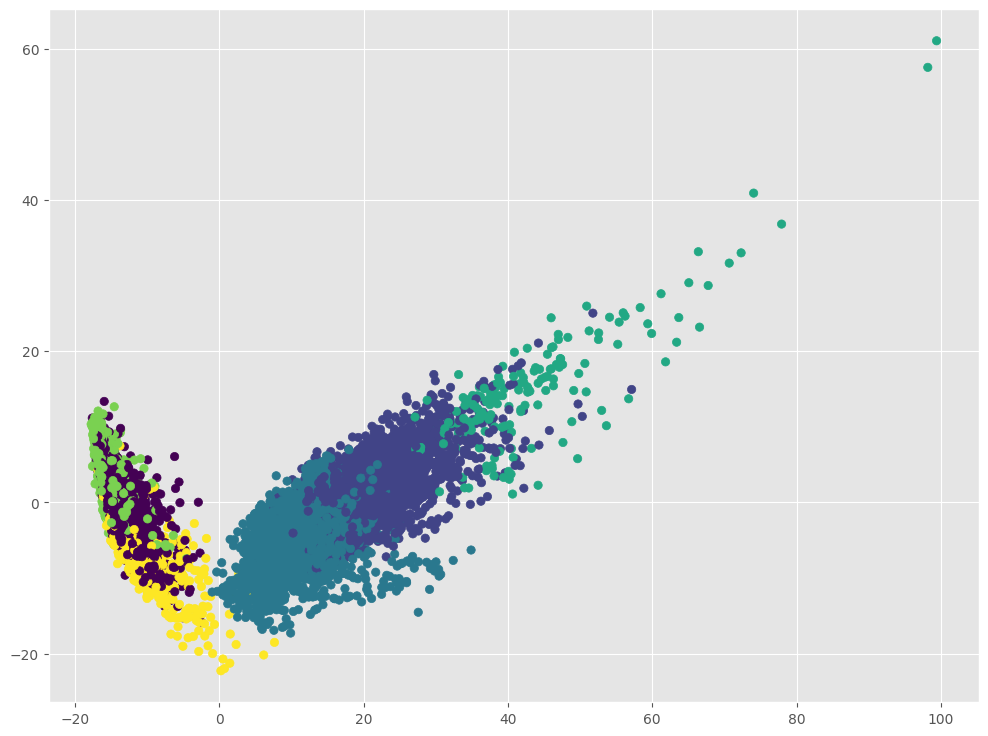

In [138]:
plt.scatter(X_pca[:,0], X_pca[:,1], c=ag_y, cmap='viridis')

Выведите метрики качества для полученного разбиения на кластеры. Сравните с kmeans. Запишите выводы!

In [126]:
print("Homogeneity: %0.3f" % metrics.homogeneity_score(y, ag_y))
print("Completeness: %0.3f" % metrics.completeness_score(y, ag_y))
print("V-measure: %0.3f" % metrics.v_measure_score(y, agy))
print("Adjusted Rand-Index: %.3f" % metrics.adjusted_rand_score(y, ag_y))
print("Adjusted mutual info score: %.3f" % metrics.adjusted_mutual_info_score(y, ag_y))
print("Silhouette Coefficient: %0.3f" % metrics.silhouette_score(X_pca, ag_y, sample_size=1000))

Homogeneity: 0.583
Completeness: 0.665
V-measure: 0.621
Adjusted Rand-Index: 0.488
Adjusted mutual info score: 0.621
Silhouette Coefficient: 0.144


Результаты AgglomerativeClustering лучше KMeans  

Попробуйте применить другие методы кластеризации из sklearn. Также вычислите метрики качества и сделайте вывод о том, какой метод сработал лучше.

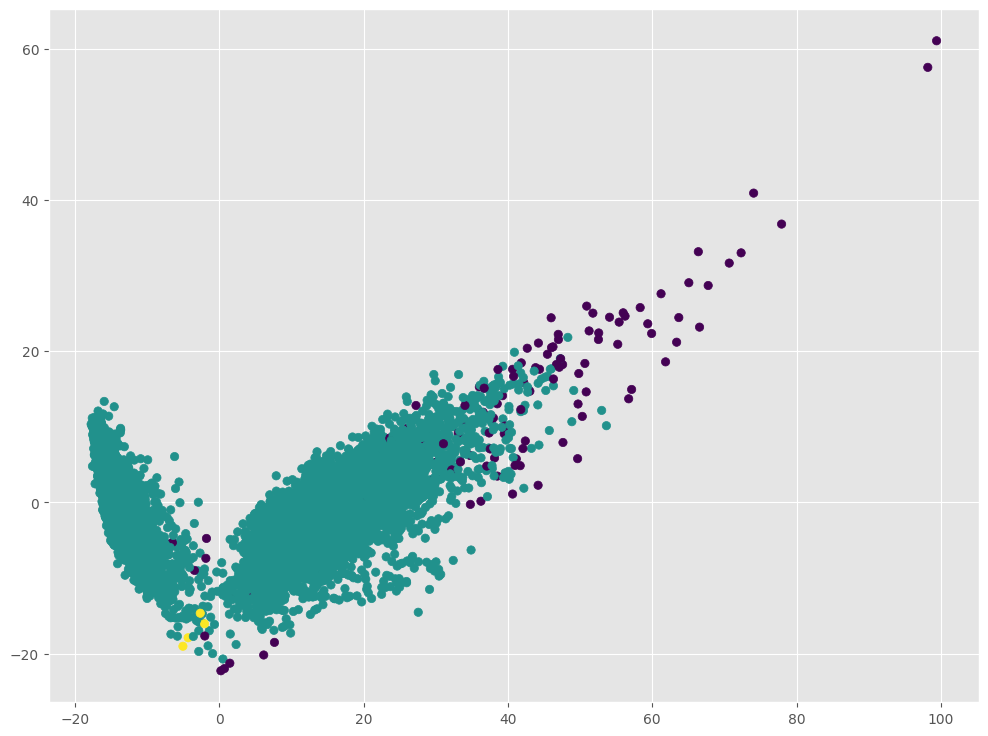

In [127]:
#DBSCAN
from sklearn.cluster import DBSCAN
db = DBSCAN(eps=20, min_samples=3)
dbscan_y = db.fit_predict(X_pca)

plt.scatter(X_pca[:,0], X_pca[:,1], c=dbscan_y, cmap='viridis')

In [128]:
print("Homogeneity: %0.3f" % metrics.homogeneity_score(y, dbscan_y))
print("Completeness: %0.3f" % metrics.completeness_score(y, dbscan_y))
print("V-measure: %0.3f" % metrics.v_measure_score(y, dbscan_y))
print("Adjusted Rand-Index: %.3f" % metrics.adjusted_rand_score(y, dbscan_y))
print("Adjusted mutual info score: %.3f" % metrics.adjusted_mutual_info_score(y, dbscan_y))
print("Silhouette Coefficient: %0.3f" % metrics.silhouette_score(X_pca, dbscan_y, sample_size=1000))

Homogeneity: 0.007
Completeness: 0.177
V-measure: 0.013
Adjusted Rand-Index: 0.001
Adjusted mutual info score: 0.012
Silhouette Coefficient: 0.485


In [129]:
#MeanShift
from sklearn.cluster import MeanShift
from sklearn.cluster import estimate_bandwidth

bandwidth = estimate_bandwidth(X_pca, quantile=0.2, n_samples=len(X_pca))
mean_shift = MeanShift(bandwidth=bandwidth)
ms_y = mean_shift.fit_predict(X_pca)

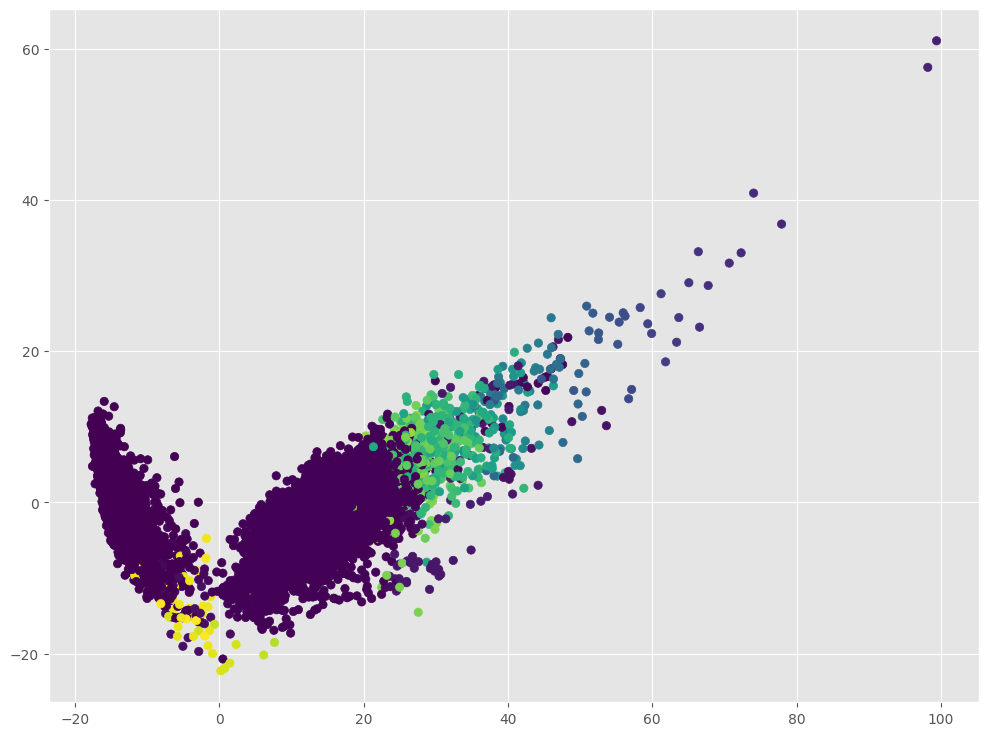

In [130]:
plt.scatter(X_pca[:,0], X_pca[:,1], c=ms_y, cmap='viridis')

In [131]:
print("Homogeneity: %0.3f" % metrics.homogeneity_score(y, ms_y))
print("Completeness: %0.3f" % metrics.completeness_score(y, ms_y))
print("V-measure: %0.3f" % metrics.v_measure_score(y, ms_y))
print("Adjusted Rand-Index: %.3f" % metrics.adjusted_rand_score(y, ms_y))
print("Adjusted mutual info score: %.3f" % metrics.adjusted_mutual_info_score(y, ms_y))
print("Silhouette Coefficient: %0.3f" % metrics.silhouette_score(X_pca, ms_y, sample_size=1000))

Homogeneity: 0.416
Completeness: 0.608
V-measure: 0.494
Adjusted Rand-Index: 0.321
Adjusted mutual info score: 0.484
Silhouette Coefficient: 0.292


Для самой успешной из полученных кластеризаций попробуйте дать интерпретацию кластеров. Опишите характеристики объектов, попавших в каждый кластер. Для этого можете ответить на следующие вопросы:

Самая успешная - AgglomerativeClustering

* похожи ли объекты внутри каждого кластера на определенный тип активности человека? - да
* в каких кластерах смешано несколько типов активности? С чем, на ваш взгляд, это может быть связано? - на графике TSNE видно, что данные разделены как бы на две группы, возможно, по типу активности: движение (ходьба, подъем/спуск по лестнице) и покой (сидение, стояние, лежание)
* качественная ли получилась кластеризация? На основании чего вы можете сделать такой вывод? - думаю, да, так как в целом кластеры сгруппированы достаточно плотно, хотя смешения есть

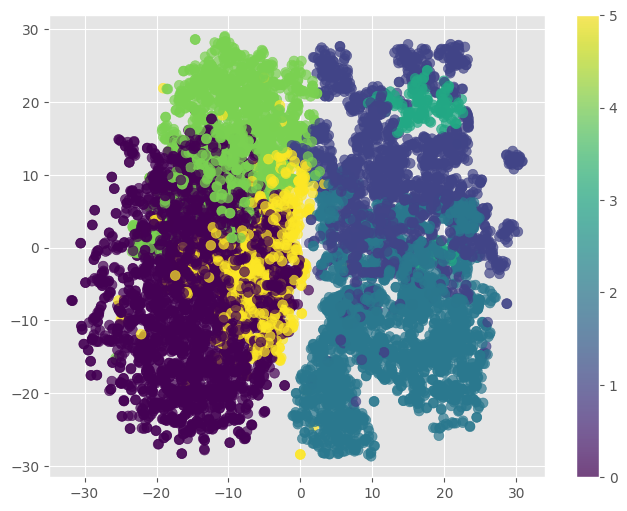

In [134]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=3, random_state=RANDOM_STATE)
X_tsne = tsne.fit_transform(X_pca)

plt.figure(figsize=(8,6))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=ag_y, cmap='viridis', alpha=0.7, s=50)
plt.colorbar()
plt.show()
